In [19]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
df = pd.read_csv("TestAnomalyUnlabled.csv")
df.info()
df= df.dropna()
anomaly_inputs = ['temperature_c','humidity_pct','pressure_hpa']
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(df[anomaly_inputs])
df['anomaly_scores'] = model.decision_function(df[anomaly_inputs])
df['anomaly'] = model.predict(df[anomaly_inputs])
df.loc[:,['timestamp','temperature_c','humidity_pct','pressure_hpa','anomaly_scores','anomaly']]
print(df["temperature_c"].min(),df["temperature_c"].max())
print(df["humidity_pct"].min(),df["humidity_pct"].max())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      1000 non-null   str    
 1   temperature_c  1000 non-null   float64
 2   humidity_pct   1000 non-null   float64
 3   pressure_hpa   1000 non-null   float64
dtypes: float64(3), str(1)
memory usage: 31.4 KB
26.44586489173849 48.31487933637854
28.276801231091905 75.4789281497209


In [15]:
def outlier_plot(data,outlier_method_name,x_var,y_var,xaxis_limits =[0,1],yaxis_limits=[0,1]):
    print("Outlier Method: ",outlier_method_name)
    print(f'{outlier_method_name}_anomaly')
    print(f"No. of anomalous values: {len(data[data['anomaly']==-1])}")
    print(f"no.of non-anomalous values: {len(data[data['anomaly']==1])}")
    print(f"total number of values: {len(data)}")
    g = sns.FacetGrid(data,col='anomaly',height=4,hue='anomaly', hue_order=[1,-1])
    g.map(sns.scatterplot, x_var, y_var)
    g.fig.suptitle(f"outlier method: {outlier_method_name}", y=1.10, fontweight = 'bold')
    g.set(xlim=xaxis_limits, ylim=yaxis_limits)
    axes = g.axes.flatten()
    axes[0].set_title(f"Outliers: {len(data[data['anomaly']==-1])}points")
    axes[1].set_title(f"Non-Outliers: {len(data[data['anomaly']==1])}points")
    return g
    

Outlier Method:  Isolation Forest
Isolation Forest_anomaly
No. of anomalous values: 100
no.of non-anomalous values: 900
total number of values: 1000


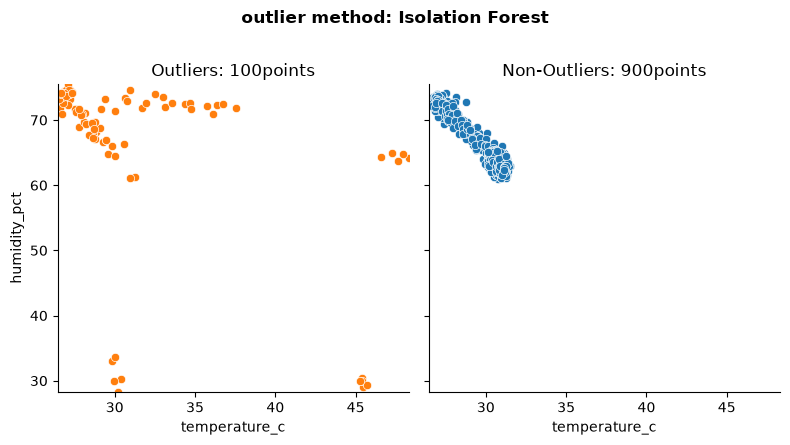

In [20]:
outlier_plot(df,"Isolation Forest","temperature_c","humidity_pct",[26.44586489173849,48.31487933637854],[28.276801231091905,75.4789281497209])


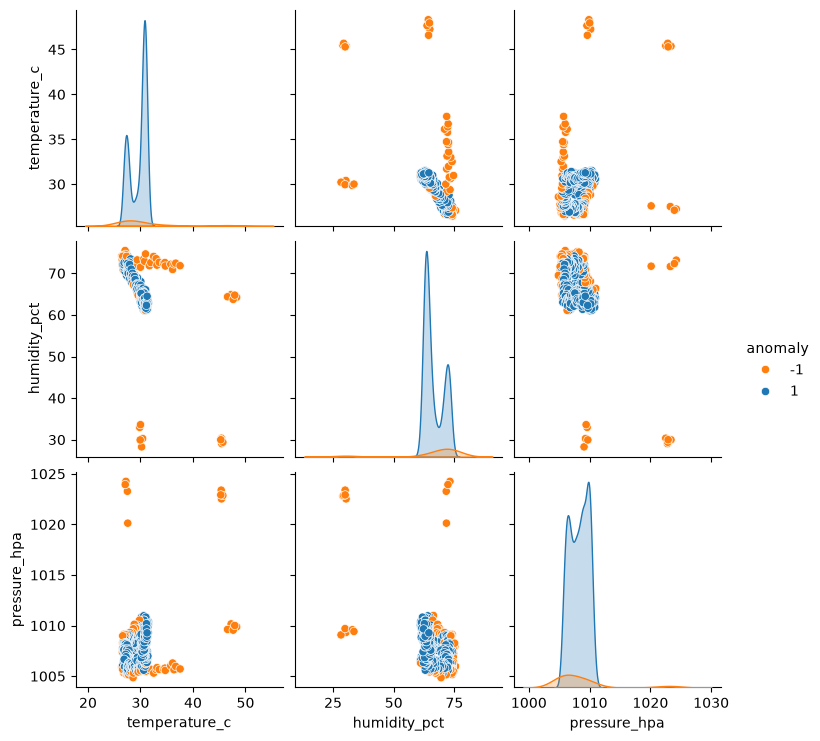

In [21]:
palette = ['#ff7f0e','#1f77b4']
sns.pairplot(df, vars = anomaly_inputs, hue = 'anomaly', palette = palette)